# AstroCLIMB - Qwen3-VL-4B-Thinking (Phase 2, Few-Shot Prompting)

**Model:** `Qwen/Qwen3-VL-4B-Thinking` (4B, ~8GB bfloat16, native `<think>` reasoning)

**Dataset:** OLD 7-column CSV (`train.csv`), 1800 balanced (450/label), base64 images

**Hardware:** Kaggle 2x T4 (15.6GB each), `device_map="auto"`, bfloat16

**NO HF_TOKEN required** (Apache 2.0, public)

**Classes (submission order):** `same_figure, same_paper, related_papers, unrelated_papers`

In [1]:
# --- 1. Setup ---
import os, json, time, re, gc, base64, sys
from pathlib import Path
from io import BytesIO
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from PIL import Image
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import torch

print(f"torch {torch.__version__} cuda {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print([torch.cuda.get_device_name(i) for i in range(torch.cuda.device_count())])
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
else:
    raise SystemExit("STOP - Enable GPU T4 x2")
assert torch.cuda.device_count() >= 2, "REQUIRE 2x T4"

import transformers
print(f"transformers {transformers.__version__}")

try:
    from transformers.models.qwen3_vl.configuration_qwen3_vl import Qwen3VLConfig
    print("Qwen3-VL config OK")
except Exception as e:
    print(f"Qwen3-VL not supported ({e}), installing from source...")
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/huggingface/transformers.git", "accelerate"])
    raise SystemExit("Restart kernel now")

os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"
print("PYTORCH_ALLOC_CONF set")

torch 2.10.0+cu128 cuda True
['Tesla T4', 'Tesla T4']
VRAM: 15.6 GB
transformers 5.0.0
Qwen3-VL config OK
PYTORCH_ALLOC_CONF set


In [2]:
# --- 2. Data loading (DUAL dataset) ---
NEW_CSV = "/kaggle/input/datasets/jcxiv42/astroclimb/astroclimb_4class(sampled).csv"
NEW_IMG_DIR = "/kaggle/input/datasets/jcxiv42/astroclimb/object_images_sampled/object_images_sampled"
OLD_CSV = "/kaggle/input/competitions/astroclimb/train.csv"

new_df = pd.read_csv(NEW_CSV)
print(f"NEW dataset (few-shot source): {new_df.shape}")
print(new_df["label_name"].value_counts())

train = pd.read_csv(OLD_CSV)
print(f"\nOLD dataset (evaluation): {train.shape}")
print(train.columns.tolist())
display(train.head(2))

label_cols = ["same_figure", "same_paper", "related_papers", "unrelated_papers"]
train["label"] = train[label_cols].idxmax(axis=1)
train["label_id"] = train["label"].map({c: i for i, c in enumerate(label_cols)})
print(train["label"].value_counts())
print(train[label_cols].sum())

NEW dataset (few-shot source): (1800, 23)
label_name
same figure         450
related papers      450
same paper          450
unrelated papers    450
Name: count, dtype: int64

OLD dataset (evaluation): (10000, 7)
['id', 'same_figure', 'same_paper', 'related_papers', 'unrelated_papers', 'obj_1', 'obj_2']


,id,same_figure,same_paper,related_papers,unrelated_papers,obj_1,obj_2
0,0,1,0,0,0,Distribution of the RVs for TOI-2046b in the t...,iVBORw0KGgoAAAANSUhEUgAACVYAAAZUCAIAAACPYVwUAA...
1,1,1,0,0,0,Vertical structures of the Martian background ...,iVBORw0KGgoAAAANSUhEUgAABwgAAAQ2CAIAAACoaX6RAA...


label
same_paper          3000
related_papers      3000
unrelated_papers    3000
same_figure         1000
Name: count, dtype: int64
same_figure         1000
same_paper          3000
related_papers      3000
unrelated_papers    3000
dtype: int64


In [3]:
# --- 3. Helpers ---
def is_image_str(s):
    if not isinstance(s, str) or len(s) < 200:
        return False
    return s.strip().startswith("iVBORw0KGgo")

def convert_str_to_PIL(img_str):
    return Image.open(BytesIO(base64.b64decode(img_str))).convert("RGB")

def load_image_from_uuid(uuid, img_dir=NEW_IMG_DIR):
    img_path = Path(img_dir) / f"{uuid}.png"
    if img_path.exists():
        return Image.open(img_path).convert("RGB")
    return None

train["obj_1_is_img"] = train["obj_1"].apply(is_image_str)
train["obj_2_is_img"] = train["obj_2"].apply(is_image_str)
train["pair_type"] = train.apply(lambda r: ("IMG" if r["obj_1_is_img"] else "TXT") + "-" + ("IMG" if r["obj_2_is_img"] else "TXT"), axis=1)
print("OLD pair types:", train["pair_type"].value_counts().to_dict())

def get_new_pair_type(t1, t2):
    if t1 == "figure" and t2 == "caption": return "FIG-CAP"
    if t1 == "caption" and t2 == "figure": return "CAP-FIG"
    if t1 == "figure" and t2 == "figure": return "FIG-FIG"
    if t1 == "caption" and t2 == "caption": return "CAP-CAP"
    return "UNKNOWN"

new_df["pair_type"] = new_df.apply(lambda r: get_new_pair_type(r["object_1_type"], r["object_2_type"]), axis=1)
print("NEW pair types:", new_df["pair_type"].value_counts().to_dict())

OLD pair types: {'TXT-IMG': 4000, 'IMG-IMG': 3000, 'TXT-TXT': 3000}
NEW pair types: {'FIG-CAP': 450, 'CAP-FIG': 450, 'CAP-CAP': 450, 'FIG-FIG': 450}


In [4]:
# --- 3b. Balanced sampler (1800 = 450/class) ---
def sample_balanced(df, n_per_class=450, seed=42):
    import pandas as pd
    assert n_per_class % 3 == 0, "n_per_class must be divisible by 3"
    parts = []
    for label in ["same_figure", "same_paper", "related_papers", "unrelated_papers"]:
        sub = df[df["label"] == label]
        if label == "same_figure":
            parts.append(sub[sub["pair_type"] == "TXT-IMG"].sample(n=n_per_class, random_state=seed))
        else:
            per_pair = n_per_class // 3
            for pt in ["TXT-IMG", "IMG-IMG", "TXT-TXT"]:
                g = sub[sub["pair_type"] == pt]
                if len(g) < per_pair:
                    print(f"Warning: {label} {pt} has {len(g)} < {per_pair}, taking all")
                    parts.append(g)
                else:
                    parts.append(g.sample(n=per_pair, random_state=seed))
    bal = pd.concat(parts).sample(frac=1, random_state=seed).reset_index(drop=True)
    return bal

train_bal = sample_balanced(train, n_per_class=450, seed=42)
print(f"train_bal {train_bal.shape} (target 1800 = 450*4)")
print(train_bal["label"].value_counts())
print(pd.crosstab(train_bal["label"], train_bal["pair_type"]))
print(f"Estimated time: {len(train_bal)*12.5/3600:.1f}h at 12.5s/it")

train_bal (1800, 12) (target 1800 = 450*4)
label
unrelated_papers    450
related_papers      450
same_paper          450
same_figure         450
Name: count, dtype: int64
pair_type         IMG-IMG  TXT-IMG  TXT-TXT
label                                      
related_papers        150      150      150
same_figure             0      450        0
same_paper            150      150      150
unrelated_papers      150      150      150
Estimated time: 6.2h at 12.5s/it


In [5]:
# --- 4. System Prompt + Few-Shot Examples from NEW Dataset ---
SYSTEM_PROMPT = """You are an expert in astrophysics figures and captions. Given Object A and Object B (each is either a figure image or a caption text), classify their relation into exactly ONE label based ONLY on what you see/read - no DOI or metadata is provided.

Classes:
- same_figure: The caption directly describes the figure in front of you. Visual elements (axes, labels, numbers, morphology) are mentioned verbatim in the text, or the text reads like "Figure X shows..." matching the image.
- same_paper: Same study, different figures. Similar writing style, same instruments/datasets/authors hinted in text, or visual style (fonts, colors, layout) is consistent, but NOT a direct caption-figure match.
- related_papers: Different papers where one builds on the other. Overlapping methods, shared datasets, or a figure/caption that looks like a cited prior result, but style/authors differ.
- unrelated_papers: No clear link. Different topics, instruments, scales, or writing/visual style with no overlap.

Base your decision only on visual and textual content. Do not assume same_figure is impossible for any pair type - judge from alignment.
Output ONLY the lowercase label (e.g., related_papers), no explanation, no punctuation."""

# Sample few-shot examples from NEW dataset (1 per class)
FEW_SHOT_EXAMPLES = []
FEW_SHOT_PER_CLASS = 1
few_shot_seed = 42
for label in ["same_figure", "same_paper", "related_papers", "unrelated_papers"]:
    label_with_space = label.replace("_", " ")
    candidates = new_df[new_df["label_name"] == label_with_space].sample(n=min(FEW_SHOT_PER_CLASS * 3, len(new_df[new_df["label_name"] == label_with_space])), random_state=few_shot_seed)
    fig_cap = candidates[candidates["pair_type"].isin(["FIG-CAP", "CAP-FIG"])]
    if len(fig_cap) >= FEW_SHOT_PER_CLASS:
        examples = fig_cap.sample(n=FEW_SHOT_PER_CLASS, random_state=few_shot_seed)
    elif len(candidates) > 0:
        examples = candidates.sample(n=FEW_SHOT_PER_CLASS, random_state=few_shot_seed)
    else:
        continue
    for _, ex_row in examples.iterrows():
        img1 = load_image_from_uuid(ex_row["object_1_uuid"])
        img2 = load_image_from_uuid(ex_row["object_2_uuid"])
        FEW_SHOT_EXAMPLES.append({
            "label": label,
            "obj_1": str(ex_row["object_1_content"])[:2000] if ex_row["object_1_type"] == "caption" else img1,
            "obj_2": str(ex_row["object_2_content"])[:2000] if ex_row["object_2_type"] == "caption" else img2,
            "obj_1_is_img": ex_row["object_1_type"] == "figure",
            "obj_2_is_img": ex_row["object_2_type"] == "figure"
        })

print(f"Sampled {len(FEW_SHOT_EXAMPLES)} few-shot examples from NEW dataset:")
for ex in FEW_SHOT_EXAMPLES:
    print(f"  {ex['label']}: obj1_img={ex['obj_1_is_img']}, obj2_img={ex['obj_2_is_img']}")
print("System prompt:", SYSTEM_PROMPT[:400])

# --- FEW-SHOT VERIFICATION (visible in logs) ---
print(f"\n{'='*60}")
print(f"FEW-SHOT IN PROMPT: {len(FEW_SHOT_EXAMPLES)} examples (1 per class) from NEW dataset")
for ex in FEW_SHOT_EXAMPLES:
    if ex['obj_1_is_img']:
        t1 = f"[FIG {ex['obj_1'].size if hasattr(ex['obj_1'],'size') else 'PIL'}]"
    else:
        t1 = str(ex['obj_1'])[:120].replace(chr(10),' ')
    if ex['obj_2_is_img']:
        t2 = f"[FIG {ex['obj_2'].size if hasattr(ex['obj_2'],'size') else 'PIL'}]"
    else:
        t2 = str(ex['obj_2'])[:120].replace(chr(10),' ')
    print(f"  [{ex['label']:16}] A: {t1[:80]} | B: {t2[:80]}")
print(f"{'='*60}")
print(f"EVALUATION DATASET: OLD train.csv balanced 1800 (450 per class) -> train_bal")
print(f"FEW-SHOT SOURCE  : NEW dataset (23-col, UUID images) -> 4 examples injected as user/assistant turns")


Sampled 4 few-shot examples from NEW dataset:
  same_figure: obj1_img=True, obj2_img=False
  same_paper: obj1_img=False, obj2_img=False
  related_papers: obj1_img=False, obj2_img=False
  unrelated_papers: obj1_img=True, obj2_img=False
System prompt: You are an expert in astrophysics figures and captions. Given Object A and Object B (each is either a figure image or a caption text), classify their relation into exactly ONE label based ONLY on what you see/read - no DOI or metadata is provided.

Classes:
- same_figure: The caption directly describes the figure in front of you. Visual elements (axes, labels, numbers, morphology) are mentioned ve

FEW-SHOT IN PROMPT: 4 examples (1 per class) from NEW dataset
  [same_figure     ] A: [FIG (1817, 1293)] | B: Polarization profiles of FRB 20201124A burst #1. The PA swing and the profile of
  [same_paper      ] A: Polarized intensity around the HH 211 envelope in Band 3 with a robust parameter | B: Spectral index components between 97.5 and 233 

In [6]:
# --- 5. Model loading (Qwen3-VL-4B-Thinking, official bfloat16, 2xT4) ---
from transformers import AutoProcessor, Qwen3VLForConditionalGeneration

MODEL_ID = "Qwen/Qwen3-VL-4B-Thinking"
ENABLE_THINKING = True
BATCH_SIZE = 1
MAX_NEW_TOKENS = 512

device = "cuda"
print(f"Loading {MODEL_ID}")
print(f"Thinking={ENABLE_THINKING} batch={BATCH_SIZE} max_tokens={MAX_NEW_TOKENS}")

processor = AutoProcessor.from_pretrained(MODEL_ID, trust_remote_code=True)
print(f"Processor loaded: {type(processor).__name__}")

# Official model, no quantization - loads in bfloat16 (~8GB), fits on T4
model = Qwen3VLForConditionalGeneration.from_pretrained(
    MODEL_ID, device_map="auto",
    torch_dtype=torch.bfloat16, trust_remote_code=True
)
model.eval()
print(f"Model loaded: {type(model).__name__}, has generate: {hasattr(model, 'generate')}")

Loading Qwen/Qwen3-VL-4B-Thinking
Thinking=True batch=1 max_tokens=512


preprocessor_config.json:   0%|          | 0.00/390 [00:00<?, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/713 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/270 [00:00<?, ?B/s]

Model loaded: Qwen3VLForConditionalGeneration, has generate: True


In [7]:
# --- 6. Messages builder ---
def build_user_content(row):
    parts = []
    for col, name in [("obj_1", "Object A"), ("obj_2", "Object B")]:
        s = row[col]
        if row[f"{col}_is_img"]:
            parts.append({"name": name, "is_img": True, "pil": convert_str_to_PIL(s)})
        else:
            txt = str(s)[:2000]
            parts.append({"name": name, "is_img": False, "text": txt})
    return parts

def build_few_shot_messages(examples):
    """Build few-shot example messages (handles PIL images from NEW dataset)"""
    messages = []
    for ex in examples:
        user_content = [{"type": "text", "text": "Classify this pair:\n"}]
        if ex["obj_1_is_img"]:
            im = ex["obj_1"]  # Already PIL from load_image_from_uuid
            if im is not None:
                im = im.copy()
                im.thumbnail((448, 448))
                user_content.append({"type": "image", "image": im})
            user_content.append({"type": "text", "text": "\nObject A: [Figure image]"})
        else:
            user_content.append({"type": "text", "text": "\nObject A (caption): " + str(ex["obj_1"])[:1000]})
        if ex["obj_2_is_img"]:
            im = ex["obj_2"]  # Already PIL from load_image_from_uuid
            if im is not None:
                im = im.copy()
                im.thumbnail((448, 448))
                user_content.append({"type": "image", "image": im})
            user_content.append({"type": "text", "text": "\nObject B: [Figure image]"})
        else:
            user_content.append({"type": "text", "text": "\nObject B (caption): " + str(ex["obj_2"])[:1000]})
        user_content.append({"type": "text", "text": "\nAnswer with one label:"})
        messages.append({"role": "user", "content": user_content})
        messages.append({"role": "assistant", "content": [{"type": "text", "text": ex["label"]}]})
    return messages

def build_messages_qwen3(row):
    messages = []
    messages.append({"role": "user", "content": [{"type": "text", "text": SYSTEM_PROMPT}]})
    messages.append({"role": "assistant", "content": [{"type": "text", "text": "Understood. I will classify pairs based on visual and textual content."}]})
    few_shot_msgs = build_few_shot_messages(FEW_SHOT_EXAMPLES)
    messages.extend(few_shot_msgs)
    
    test_content = [{"type": "text", "text": "Classify this pair:\n"}]
    parts = build_user_content(row)
    for p in parts:
        if p["is_img"]:
            im = p["pil"].copy()
            im.thumbnail((448, 448))
            test_content.append({"type": "image", "image": im})
            test_content.append({"type": "text", "text": "\n" + p["name"] + ": [Figure image]"})
        else:
            test_content.append({"type": "text", "text": "\n" + p["name"] + " (caption): " + p["text"]})
    test_content.append({"type": "text", "text": "\nAnswer with one label:"})
    messages.append({"role": "user", "content": test_content})
    return messages

print("Message builder OK (with few-shot examples)")

# --- FEW-SHOT MESSAGE VERIFICATION ---
_dbg_row = train_bal.iloc[0]
_dbg_msgs = build_messages_qwen3(_dbg_row)
print(f"FEW-SHOT MESSAGE VERIFICATION: total messages={len(_dbg_msgs)} (expect 2 sys+ack + 8 few-shot (4 pairs) +1 test =11)")
for _i, _m in enumerate(_dbg_msgs):
    _role = _m['role']
    _has_img = any(p.get('type')=='image' for p in _m['content'])
    _txt = ''
    for _p in _m['content']:
        if _p.get('type')=='text':
            _txt = _p['text'][:100].replace(chr(10),' ')
            break
    print(f"  msg[{_i:2}] {_role:9} img={_has_img} | {_txt[:80]}")
print(f"Few-shot injection OK: {len(FEW_SHOT_EXAMPLES)} examples -> {len(FEW_SHOT_EXAMPLES)*2} messages")
del _dbg_row, _dbg_msgs


Message builder OK (with few-shot examples)
FEW-SHOT MESSAGE VERIFICATION: total messages=11 (expect 2 sys+ack + 8 few-shot (4 pairs) +1 test =11)
  msg[ 0] user      img=False | You are an expert in astrophysics figures and captions. Given Object A and Objec
  msg[ 1] assistant img=False | Understood. I will classify pairs based on visual and textual content.
  msg[ 2] user      img=True | Classify this pair: 
  msg[ 3] assistant img=False | same_figure
  msg[ 4] user      img=False | Classify this pair: 
  msg[ 5] assistant img=False | same_paper
  msg[ 6] user      img=False | Classify this pair: 
  msg[ 7] assistant img=False | related_papers
  msg[ 8] user      img=True | Classify this pair: 
  msg[ 9] assistant img=False | unrelated_papers
  msg[10] user      img=True | Classify this pair: 
Few-shot injection OK: 4 examples -> 8 messages


In [8]:
# --- 7. Inference ---
label_pattern = re.compile(r"(same_figure|same_paper|related_papers|unrelated_papers)", re.IGNORECASE)

def parse_label(text):
    m = label_pattern.search(text.lower())
    return m.group(1).lower() if m else "unrelated_papers"

raw_outputs = []
start_time = time.time()

def predict_qwen3(df, batch_size=BATCH_SIZE, save_every=1000, save_path="preds_train.npy", raw_path="raw_outputs.jsonl"):
    preds = []
    for i in tqdm(range(0, len(df), batch_size), desc="Infer"):
        batch = df.iloc[i:i+batch_size]
        for j, (_, row) in enumerate(batch.iterrows()):
            try:
                messages = build_messages_qwen3(row)
                text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True, enable_thinking=ENABLE_THINKING)
                if i == 0 and j == 0:
                    print(f"DEBUG RENDERED PROMPT (first 2000 chars):"+ chr(10) + text[:2000])
                    print(f"DEBUG: few-shot labels in prompt: {[ex['label'] for ex in FEW_SHOT_EXAMPLES]}")
                images = []
                for turn in messages:
                    for part in turn["content"]:
                        if part.get("type") == "image" and "image" in part:
                            im = part["image"]
                            im.thumbnail((448, 448))
                            images.append(im)
                images = images if images else None
                inputs = processor(text=[text], images=images, padding=True, return_tensors="pt")
                inputs = inputs.to(model.device)
                input_len = inputs["input_ids"].shape[1]
                
                gen_kwargs = {"max_new_tokens": MAX_NEW_TOKENS, "do_sample": False, "use_cache": True}
                if ENABLE_THINKING:
                    gen_kwargs.update({"temperature": 0.6, "top_p": 0.95, "do_sample": True})
                with torch.no_grad():
                    out = model.generate(**inputs, **gen_kwargs)
                decoded = processor.batch_decode(out[:, input_len:], skip_special_tokens=True)[0]
            except RuntimeError as e:
                if "out of memory" in str(e).lower():
                    print(f"OOM at {i+j}")
                    torch.cuda.empty_cache(); gc.collect()
                    decoded = "unrelated_papers"
                else:
                    raise
            
            thinking = ""
            if "<think>" in decoded:
                parts = decoded.split("</think>")
                if len(parts) > 1:
                    thinking = parts[0].split("<think>")[-1].strip()
                    decoded = parts[-1].strip()
            pred = parse_label(decoded)
            
            raw_outputs.append({
                "true_label": str(row.get("label", "")),
                "pred": pred,
                "thinking": thinking,
                "raw": decoded
            })
            preds.append(pred)
        
        if (i // batch_size + 1) % (save_every // batch_size) == 0:
            np.save(save_path, np.array(preds))
            with open(raw_path, "w", encoding="utf-8") as f:
                for r in raw_outputs:
                    f.write(json.dumps(r, ensure_ascii=False) + "\n")
            print(f"Checkpoint {len(preds)}/{len(df)} saved")
            torch.cuda.empty_cache(); gc.collect()
        if time.time() - start_time > 6.5 * 3600:
            print("6.5h reached")
            break
    return np.array(preds)

from tqdm import tqdm
print(f"Starting inference: {len(train_bal)} samples")

Starting inference: 1800 samples


In [9]:
# --- 8. Run ---
preds_train = predict_qwen3(train_bal, batch_size=BATCH_SIZE, save_path="preds_train.npy")
print(f"Done {len(preds_train)} in {(time.time()-start_time)/3600:.2f}h")
np.save("preds_train_bal_final.npy", preds_train)
with open("raw_outputs_final.jsonl", "w", encoding="utf-8") as f:
    for r in raw_outputs:
        f.write(json.dumps(r, ensure_ascii=False) + "\n")
np.save("raw_outputs_final.npy", np.array(raw_outputs, dtype=object))
print(f"Raw saved: {len(raw_outputs)} samples")

Infer:   0%|          | 0/1800 [00:00<?, ?it/s]

DEBUG RENDERED PROMPT (first 2000 chars):
<|im_start|>user
You are an expert in astrophysics figures and captions. Given Object A and Object B (each is either a figure image or a caption text), classify their relation into exactly ONE label based ONLY on what you see/read - no DOI or metadata is provided.

Classes:
- same_figure: The caption directly describes the figure in front of you. Visual elements (axes, labels, numbers, morphology) are mentioned verbatim in the text, or the text reads like "Figure X shows..." matching the image.
- same_paper: Same study, different figures. Similar writing style, same instruments/datasets/authors hinted in text, or visual style (fonts, colors, layout) is consistent, but NOT a direct caption-figure match.
- related_papers: Different papers where one builds on the other. Overlapping methods, shared datasets, or a figure/caption that looks like a cited prior result, but style/authors differ.
- unrelated_papers: No clear link. Different topics, instr

Infer:  22%|██▏       | 396/1800 [6:30:36<23:04:54, 59.18s/it]

6.5h reached
Done 397 in 6.51h
Raw saved: 397 samples


In [10]:
# --- 9. Metrics ---
y_true_all = train_bal["label"].values
y_pred_all = preds_train

if len(y_pred_all) != len(y_true_all):
    print(f"Warning: preds {len(y_pred_all)} != true {len(y_true_all)}")
    n = min(len(y_true_all), len(y_pred_all))
    y_true, y_pred = y_true_all[:n], y_pred_all[:n]
else:
    y_true, y_pred = y_true_all, y_pred_all

acc = accuracy_score(y_true, y_pred)
macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
per_class = f1_score(y_true, y_pred, average=None, labels=label_cols, zero_division=0)

print(f"Overall acc={acc:.4f} macro-F1={macro_f1:.4f} on balanced {len(y_true)}/{len(y_true_all)}")
print("Per-class F1:", dict(zip(label_cols, per_class.round(4))))
print(classification_report(y_true, y_pred, labels=label_cols, target_names=label_cols, digits=4, zero_division=0))

cm = confusion_matrix(y_true, y_pred, labels=label_cols)
cm_df = pd.DataFrame(cm, index=[f"true:{c}" for c in label_cols], columns=[f"pred:{c}" for c in label_cols])
display(cm_df)

for pt in ["TXT-IMG", "IMG-IMG", "TXT-TXT"]:
    mask = train_bal.iloc[:len(y_true)]["pair_type"] == pt
    if mask.sum() == 0: continue
    mf1 = f1_score(y_true[mask], y_pred[mask], average="macro", zero_division=0)
    print(f"{pt:8} n={mask.sum():4} macro-F1={mf1:.4f}")

metrics = {"model": MODEL_ID, "overall": {"acc": float(acc), "macro_f1": float(macro_f1),
    "per_class": dict(zip(label_cols, per_class.tolist()))},
    "n_train": int(len(y_true)), "n_total": int(len(y_true_all)),
    "truncated": bool(len(y_pred_all) != len(y_true_all)),
    "time_h": float((time.time() - start_time) / 3600)}
Path("metrics.json").write_text(json.dumps(metrics, indent=2))
print(json.dumps(metrics, indent=2))

Overall acc=0.3300 macro-F1=0.2497 on balanced 397/1800
Per-class F1: {'same_figure': np.float64(0.4709), 'same_paper': np.float64(0.2381), 'related_papers': np.float64(0.0612), 'unrelated_papers': np.float64(0.2286)}
                  precision    recall  f1-score   support

     same_figure     0.3142    0.9394    0.4709        99
      same_paper     0.6818    0.1442    0.2381       104
  related_papers     0.6000    0.0323    0.0612        93
unrelated_papers     0.2703    0.1980    0.2286       101

        accuracy                         0.3300       397
       macro avg     0.4666    0.3285    0.2497       397
    weighted avg     0.4663    0.3300    0.2523       397



,pred:same_figure,pred:same_paper,pred:related_papers,pred:unrelated_papers
true:same_figure,93,1,0,5
true:same_paper,64,15,2,23
true:related_papers,59,5,3,26
true:unrelated_papers,80,1,0,20


TXT-IMG  n= 205 macro-F1=0.2354
IMG-IMG  n=  89 macro-F1=0.0813
TXT-TXT  n= 103 macro-F1=0.2148
{
  "model": "Qwen/Qwen3-VL-4B-Thinking",
  "overall": {
    "acc": 0.32997481108312343,
    "macro_f1": 0.249694308102988,
    "per_class": {
      "same_figure": 0.4708860759493671,
      "same_paper": 0.23809523809523808,
      "related_papers": 0.061224489795918366,
      "unrelated_papers": 0.22857142857142856
    }
  },
  "n_train": 397,
  "n_total": 1800,
  "truncated": true,
  "time_h": 6.510280956625938
}


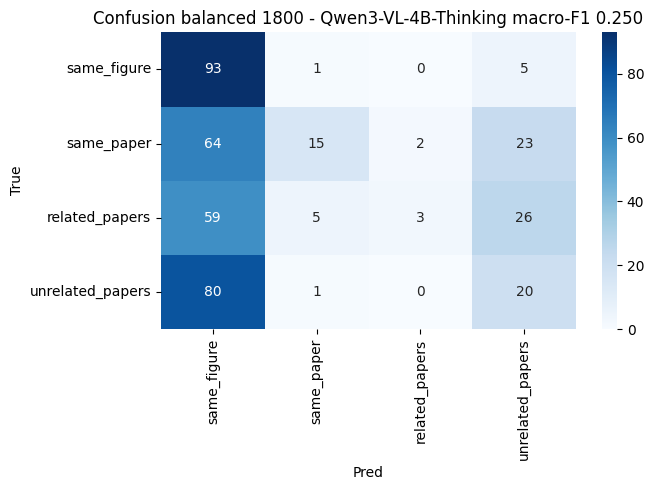

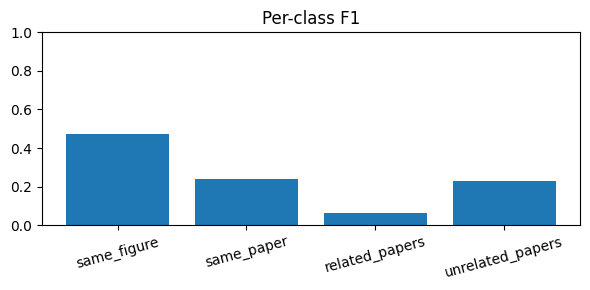

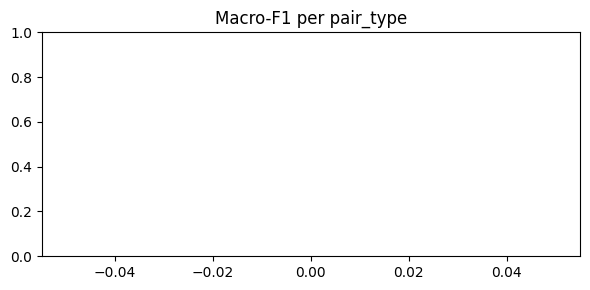

Saved plots


In [11]:
# --- 10. Visualization ---
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_cols, yticklabels=label_cols)
plt.title(f"Confusion balanced 1800 - {MODEL_ID.split('/')[-1]} macro-F1 {macro_f1:.3f}")
plt.ylabel("True"); plt.xlabel("Pred"); plt.tight_layout(); plt.savefig("confusion.png", dpi=150); plt.show()

plt.figure(figsize=(6, 3))
plt.bar(label_cols, per_class)
plt.title("Per-class F1"); plt.ylim(0, 1); plt.xticks(rotation=15); plt.tight_layout(); plt.savefig("per_class_f1.png"); plt.show()

pts, f1s = [], []
for pt in ["TXT-IMG", "IMG-IMG", "TXT-TXT"]:
    mask = train_bal["pair_type"] == pt
    if mask.sum() > 0 and len(y_true) >= mask.sum():
        f1s.append(f1_score(y_true[mask], y_pred[mask], average="macro", zero_division=0))
        pts.append(pt)
plt.figure(figsize=(6, 3))
plt.bar(pts, f1s)
plt.title("Macro-F1 per pair_type"); plt.ylim(0, 1); plt.tight_layout(); plt.savefig("per_pair_f1.png"); plt.show()
print("Saved plots")

In [12]:
# --- 11. Summary ---
elapsed = (time.time() - start_time) / 3600
print(f"\n{'='*60}")
print(f"Model: {MODEL_ID}  Thinking: {ENABLE_THINKING}")
print(f"Time: {elapsed:.2f}h  Samples: {len(preds_train)}/{len(train_bal)}")
print(f"Overall acc={acc:.4f} macro-F1={macro_f1:.4f}")
print(f"{'='*60}")
print("Outputs: preds_train.npy, preds_train_bal_final.npy, raw_outputs.jsonl, raw_outputs_final.jsonl")
print("         metrics.json, confusion.png, per_class_f1.png, per_pair_f1.png")


Model: Qwen/Qwen3-VL-4B-Thinking  Thinking: True
Time: 6.51h  Samples: 397/1800
Overall acc=0.3300 macro-F1=0.2497
Outputs: preds_train.npy, preds_train_bal_final.npy, raw_outputs.jsonl, raw_outputs_final.jsonl
         metrics.json, confusion.png, per_class_f1.png, per_pair_f1.png
